# Naive Bayes with scikit-learn
Multinomial Naive Bayes for tweet sentiment using `sklearn` pipeline.
Model saved to `../Models/naive_bayes_sklearn.joblib`.

## 1. Load & Preprocess Tweets

In [1]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples, stopwords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os

STOPWORDS = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)   # return string — sklearn handles tokenisation

pos = twitter_samples.strings('positive_tweets.json')
neg = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame(
    [(clean(t), 1) for t in pos] + [(clean(t), 0) for t in neg],
    columns=['text', 'label']
)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total: {len(df):,}  |  Pos: {df.label.sum():,}  |  Neg: {(df.label==0).sum():,}")
df.head(3)

Total: 10,000  |  Pos: 5,000  |  Neg: 5,000


,text,label
0,love feel emm think,0
1,thanks guys,1
2,love lord better life lt,1


## 2. Train / Test Split (80/20, stratified)

In [2]:
from sklearn.model_selection import train_test_split

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Train: {len(X_raw_train):,}  |  Test: {len(X_raw_test):,}")

Train: 8,000  |  Test: 2,000


## 3. Build sklearn Pipeline

A `Pipeline` chains preprocessing and model into a single object — it ensures
the vectoriser is fit only on training data and prevents data leakage.

| Step | Component | Role |
|---|---|---|
| `tfidf` | `TfidfVectorizer` | Converts text → sparse TF-IDF matrix |
| `nb` | `MultinomialNB` | Fits Naive Bayes on the sparse matrix |

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),     # unigrams + bigrams
        sublinear_tf=True       # 1 + log(tf) instead of raw tf
    )),
    ('nb', MultinomialNB(
        alpha=1.0               # Laplace smoothing (same as our scratch impl.)
    ))
])

pipeline.fit(X_raw_train, y_train)
print('Pipeline fitted.')
print(f"Vocabulary size: {len(pipeline['tfidf'].vocabulary_):,}")

Pipeline fitted.
Vocabulary size: 5,000


## 4. Evaluation

In [4]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

for label, X_s, y_s in [('Train', X_raw_train, y_train), ('Test', X_raw_test, y_test)]:
    y_pred = pipeline.predict(X_s)
    acc    = accuracy_score(y_s, y_pred)
    auc    = roc_auc_score(y_s, pipeline.predict_proba(X_s)[:, 1])
    print(f"{label:<6} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")

Train  | Accuracy: 0.8528 | ROC-AUC: 0.9345
Test   | Accuracy: 0.7560 | ROC-AUC: 0.8416


## 5. Classification Report

In [5]:
y_pred_test = pipeline.predict(X_raw_test)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.73      0.82      0.77      1000
    Positive       0.79      0.70      0.74      1000

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



## 6. Confusion Matrix

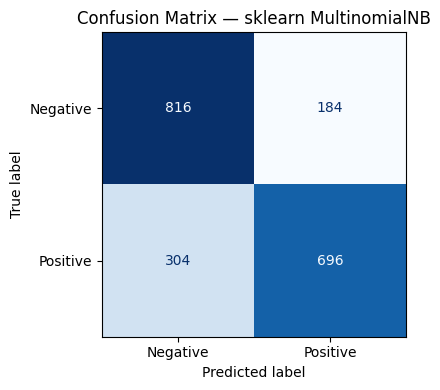

In [6]:
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — sklearn MultinomialNB')
plt.tight_layout(); plt.show()

## 7. ROC Curve

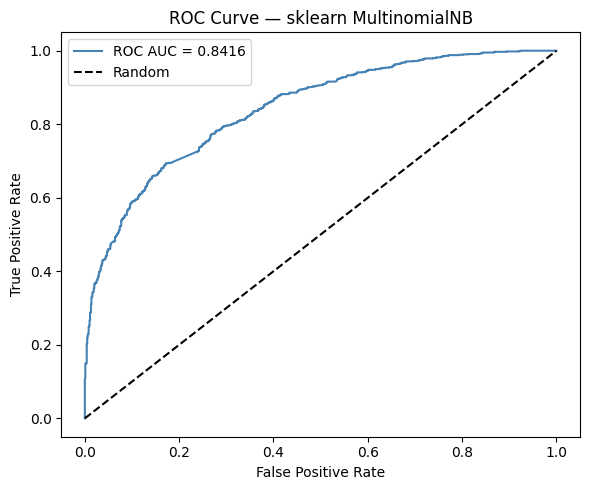

In [7]:
y_prob  = pipeline.predict_proba(X_raw_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc     = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — sklearn MultinomialNB')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Top Discriminative N-grams

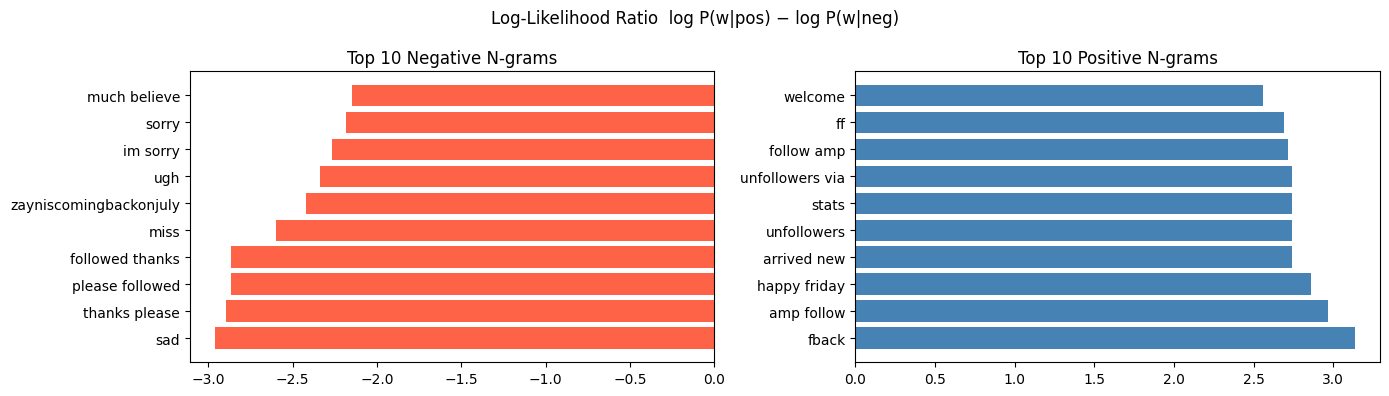

In [8]:
feature_names = pipeline['tfidf'].get_feature_names_out()
# log P(w|pos) - log P(w|neg)  — same log-likelihood ratio as scratch impl.
log_ratio = pipeline['nb'].feature_log_prob_[1] - pipeline['nb'].feature_log_prob_[0]
order     = np.argsort(log_ratio)

top_neg = [(feature_names[i], log_ratio[i]) for i in order[:10]]
top_pos = [(feature_names[i], log_ratio[i]) for i in order[-10:][::-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.barh([w for w,_ in top_neg], [s for _,s in top_neg], color='tomato')
ax1.set_title('Top 10 Negative N-grams')
ax2.barh([w for w,_ in top_pos], [s for _,s in top_pos], color='steelblue')
ax2.set_title('Top 10 Positive N-grams')
plt.suptitle('Log-Likelihood Ratio  log P(w|pos) − log P(w|neg)')
plt.tight_layout(); plt.show()

## 9. Effect of Smoothing Parameter α

`alpha` in `MultinomialNB` is the Laplace/Lidstone smoothing term.
- α = 1.0 → standard Laplace smoothing
- α → 0 → less smoothing (can overfit)
- α → large → heavier smoothing (priors dominate)

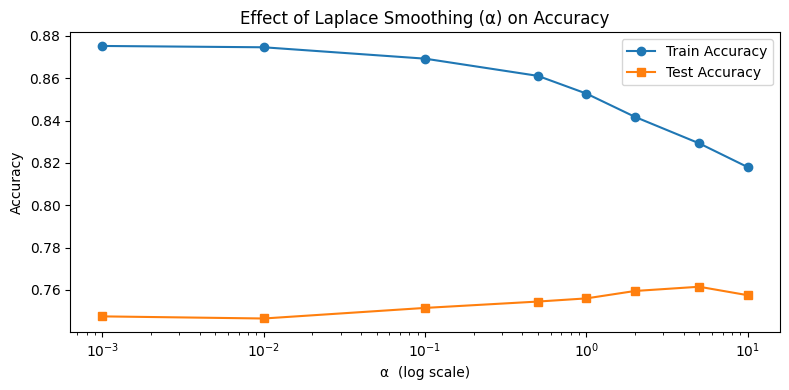

In [9]:
alphas      = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
train_accs  = []
test_accs   = []

vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xv_tr = vec.fit_transform(X_raw_train)
Xv_te = vec.transform(X_raw_test)

for a in alphas:
    m = MultinomialNB(alpha=a).fit(Xv_tr, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(Xv_tr)))
    test_accs.append(accuracy_score(y_test,  m.predict(Xv_te)))

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, train_accs, marker='o', label='Train Accuracy')
plt.semilogx(alphas, test_accs,  marker='s', label='Test Accuracy')
plt.xlabel('α  (log scale)'); plt.ylabel('Accuracy')
plt.title('Effect of Laplace Smoothing (α) on Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

## 10. Predict on Custom Tweets

In [10]:
def predict_tweet(tweet):
    cleaned = clean(tweet)
    prob    = pipeline.predict_proba([cleaned])[0, 1]
    label   = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {label}")
    print()

predict_tweet("I love this so much, absolutely amazing!")
predict_tweet("This is the worst day ever, I hate everything.")
predict_tweet("The flight was delayed but the crew was super helpful :)")
predict_tweet("Can't believe how bad the service was today. Never again.")

Tweet:       I love this so much, absolutely amazing!
Probability: 0.6242
Sentiment:   Positive 😊

Tweet:       This is the worst day ever, I hate everything.
Probability: 0.2188
Sentiment:   Negative 😞

Tweet:       The flight was delayed but the crew was super helpful :)
Probability: 0.4947
Sentiment:   Negative 😞

Tweet:       Can't believe how bad the service was today. Never again.
Probability: 0.1271
Sentiment:   Negative 😞



## 11. Save Model to `../Models/`

Saves the entire fitted pipeline (vectoriser + classifier) as a single `.joblib` file.
Load it anywhere with one line — no need to refit.

In [11]:
import joblib

save_path = '../Models/naive_bayes_sklearn.joblib'
joblib.dump(pipeline, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Pipeline saved → {save_path}  ({size_kb:.1f} KB)")

Pipeline saved → ../Models/naive_bayes_sklearn.joblib  (340.9 KB)


## 12. Reload & Verify

In [12]:
pipeline_loaded = joblib.load('../Models/naive_bayes_sklearn.joblib')

tweets   = [
    "I love this so much, absolutely amazing!",
    "This is the worst day ever, I hate everything."
]
cleaned  = [clean(t) for t in tweets]
probs    = pipeline_loaded.predict_proba(cleaned)[:, 1]
labels   = pipeline_loaded.predict(cleaned)

for tweet, prob, label in zip(tweets, probs, labels):
    sentiment = 'Positive 😊' if label == 1 else 'Negative 😞'
    print(f"[Reloaded] {tweet[:50]}")
    print(f"           prob={prob:.4f}  →  {sentiment}")
    print()

[Reloaded] I love this so much, absolutely amazing!
           prob=0.6242  →  Positive 😊

[Reloaded] This is the worst day ever, I hate everything.
           prob=0.2188  →  Negative 😞

